In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import sys
sys.path.append('../')
from src.ligand_coding_model import *
from collections import defaultdict
from IPython.display import display, Math
from itertools import combinations_with_replacement
def Normalize(curve):
    return (curve - np.min(curve))/(np.max(curve) - np.min(curve))

In [2]:
# --------------------------- main ---------------------------
# CONFIG
directory = "/mnt/hcleroy/PostDoc2/octopus_smelling/experimental_data/matlab_files/v2"
xlsx = "doseHeteromer_dataAll_v2.xlsx"
sheets = {"CR518": "CR518", "CR518_918": "CR518-918", "CR918": "CR918", "GCaMP": "GCaMP","CR518_999":"CR518-999","CR999":"CR999"}
ligandList =["Androsterone","Progesterone","Chloroquine","Strychnine","Naringin","Nootkatone","Taurocholic acid"]
nLig = len(ligandList)
# validity == True if the receptor respond to a given ligand.
validity = {
    "CR518": np.array([True for _ in range(nLig)]),
    "CR518_918":np.array([True,True,True,True,True,True,False]),
    "CR918": np.array([False,False,False,False,True,True,False]),
    "CR518_999":np.array([True for _ in range(nLig)]),
    "CR999":np.array([False,True,False,True,False,True,True])
}

# Load all DataFrames into a dictionary
dfs = {key: pd.read_excel(f"{directory}/{xlsx}", sheet_name=name, engine="openpyxl") 
       for key, name in sheets.items()}

# Helper to build indices
def get_idx_dict(df):
    col_lig = "Var2" if "Var2" in df.columns else df.columns[1]
    return [df.index[df[col_lig] == lig].to_numpy() for lig in ligandList]

# Build index dictionary of the dose data
idxs = {key: get_idx_dict(df) for key, df in dfs.items()}

# Build raw values dictionary
vals_all = {key: [dfs[key].iloc[idx, 3:].to_numpy(dtype=float) for idx in idxs[key]] 
            for key in dfs.keys()}

In [3]:
def find_c12(x,y):
    y -= np.min(y)
    target_y = np.max(y)/2.
    idx = np.where(y >= target_y)[0][0]
    f = interp1d(y[idx-1:idx+1], x[idx-1:idx+1])
    return f(target_y)

# Measure C1/2
Let us first measure C1/2 for the average curves.

In [4]:
ec50 = defaultdict(dict)
for key,valid in validity.items():
    for i, lig in enumerate(ligandList):
        if not valid[i]:
            continue
        if key not in vals_all or key not in dfs:
            print('key issue')
            continue
        raw_replicates = vals_all[key][i] # Shape: (doses, replicates)
        response = np.nanmean(raw_replicates, axis=1) # average response
        dose = dfs[key].iloc[idxs[key][i], 2].to_numpy(dtype=float) # X values
        ec50[key][lig] = find_c12(dose,response)

In [6]:
infered_ec50 = defaultdict(dict)
infered_hetero_names = [['CR518','CR918'],['CR518','CR999']]
for keys in infered_hetero_names:
    for i,ligand in enumerate(ligandList):
        if all([validity[key][i] for key in keys]):
            pool_c12 = [ec50[keys[i]][ligand] for i in range(len(keys))]
            combos = list(combinations_with_replacement(pool_c12, 5))[1:-1]
            infered_ec50[keys[0]+'_'+keys[1]][ligand] = [np.prod(combo)**(1/5) for combo in combos] + [np.mean([np.prod(combo)**(1/5) for combo in combos])]


In [18]:
dfec50 = pd.DataFrame(ec50).astype(float)

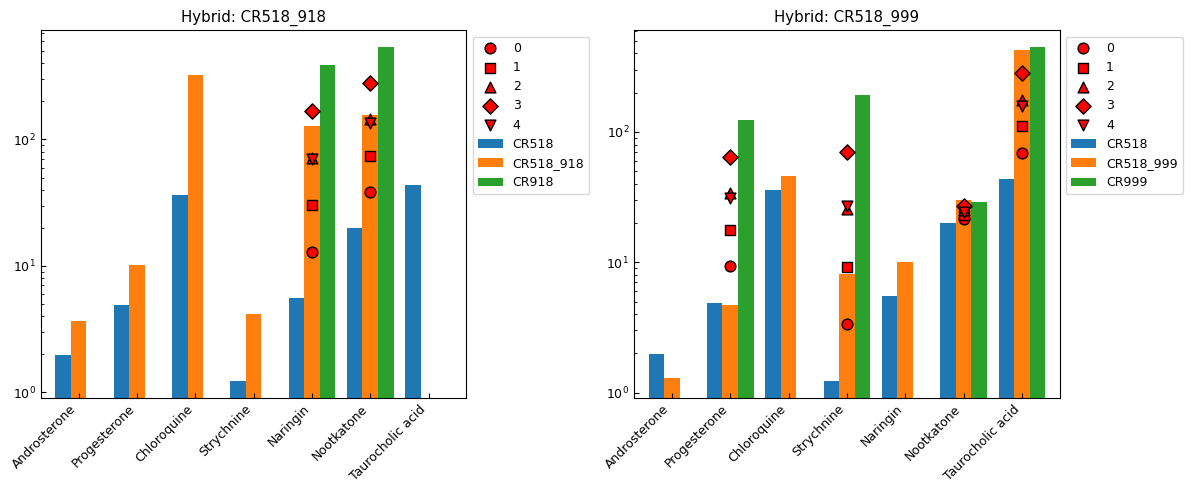

In [21]:
# 2. Plot Setup
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 5))

groups = [
    (['CR518', 'CR518_918', 'CR918'], 'CR518_CR918'), 
    (['CR518', 'CR518_999', 'CR999'], 'CR518_CR999')
]

# Define symbols for each index in the list [0, 1, 2, 3...]
# o=circle, s=square, ^=triangle, D=diamond, v=down_triangle
markers = ['o', 's', '^', 'D','v','_'] 

for i, (cols, infer_key) in enumerate(groups):
    # Plot bars
    dfec50[cols].plot(kind='bar', ax=ax[i], width=0.8, alpha=1.) # Added alpha to see points better
    
    target_col_idx = 1 # The middle bar is the target
    
    if infer_key in infered_ec50:
        for ligand, values_list in infered_ec50[infer_key].items():
            if ligand in dfec50.index:
                # Get coordinates
                x_idx = dfec50.index.get_loc(ligand)
                bars = ax[i].containers[target_col_idx]
                x_pos = bars[x_idx].get_x() + bars[x_idx].get_width() / 2
                
                # Loop over the list of values and plot each with a specific marker
                for val_idx, val in enumerate(values_list):
                    # Cycle markers if list is longer than marker list
                    m = markers[val_idx % len(markers)] 
                    # Only add label for the first time to avoid legend clutter
                    #lbl = f'Pred {val_idx+1}' if (x_idx == 0 and i == 0) else ""
                    #current_label = f"Index {val_idx + 1}" if (i == 0 and x_idx == 0) else None
                    current_label = val_idx
                    ax[i].scatter(x_pos, val, 
                                  marker=m, 
                                  color='red', 
                                  s=60, 
                                  edgecolors='black', 
                                  zorder=10,
                                  label=current_label) # Label goes here

    ax[i].tick_params(axis='x', labelrotation=45)
    plt.setp(ax[i].get_xticklabels(), ha='right')
    ax[i].set_title(f"Hybrid: {cols[1]}")
    ax[i].set_yscale('log')
    
    # Handle Legend: Filter unique labels to avoid duplicates
    handles, labels = ax[i].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax[i].legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()

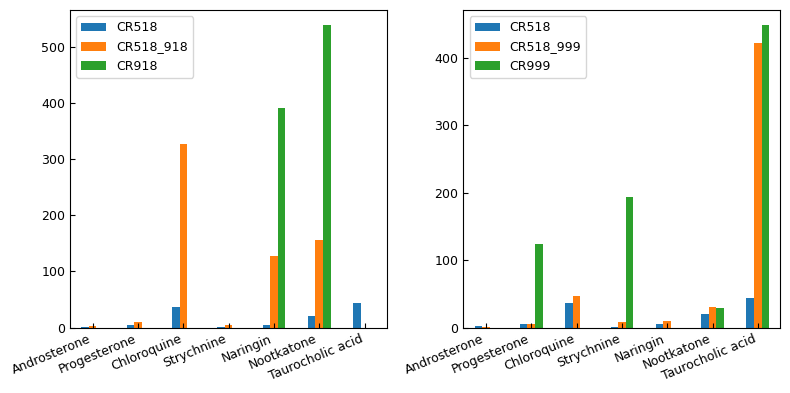

In [22]:

fig,ax = plt.subplots(ncols=2,nrows=1,figsize=(8,4))


# 2. Plot
dfec50[['CR518','CR518_918','CR918']].plot(kind='bar', ax=ax[0])
dfec50[['CR518','CR518_999','CR999']].plot(kind='bar', ax=ax[1])

for i in range(2):
    ax[i].tick_params(axis='x', labelrotation=22.5)
    plt.setp(ax[i].get_xticklabels(), ha='right')


plt.tight_layout()
plt.show()

# Investigate a specific curve

[1.7073189  1.81202377]
[ 76.03193881 165.91405795]
[ 480.91559381 4634.69168298]
[5.41487672 7.92903582]
[ 8.73798781 19.71567108]


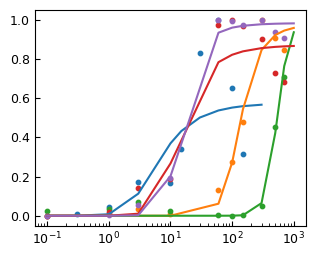

In [ ]:
def Po_fit(c,epsilon,Ko,Kc):
    eps = np.array([epsilon]*5)
    Kos = np.array([Ko]*5)
    Kcs = np.array([Kc]*5)
    return Normalize(PoHetero(c,eps,Kos,Kcs))
def Po_fit(c,Ko_,Kc):
    return (c/Ko_)**5/((c/Ko_)**5+(1+c/Kc)**5)

l_idx  = 5
p0 =[1.,1.]
for key,raw_replicates in vals_all.items():
    if key == "GCaMP":
        continue
    if not valid[l_idx]:
        continue    
    response = Normalize(np.nanmean(raw_replicates[l_idx], axis=1)[:-1])
    dose = dfs[key].iloc[idxs[key][l_idx], 2].to_numpy(dtype=float)[:-1] # X values

    plt.scatter(dose[:-1],response[:-1],s=10)

    popt,pconv = curve_fit(Po_fit,dose,response,p0=p0)
    print(popt)
    plt.plot(dose,Po_fit(dose,*popt))

    #plt.yscale('log')
    plt.xscale('log')

[6.20917468e-06 9.45998759e-06 1.43572439e-05 2.16993496e-05
 3.26499127e-05 4.88916777e-05 7.28378402e-05 1.07918025e-04
 1.58959249e-04 2.32684583e-04 3.38353145e-04 4.88563358e-04
 7.00235627e-04 9.95778979e-04 1.40442702e-03 1.96370026e-03
 2.72091373e-03 3.73460180e-03 5.07567937e-03 6.82810636e-03
 9.08878123e-03 1.19663726e-02 1.55788207e-02 2.00493202e-02
 2.55007367e-02 3.20486147e-02 3.97931814e-02 4.88109996e-02
 5.91471262e-02 7.08087213e-02 8.37609952e-02 9.79261485e-02
 1.13185594e-01 1.29385306e-01 1.46343716e-01 1.63861269e-01
 1.81730588e-01 1.99746246e-01 2.17713305e-01 2.35454064e-01
 2.52812783e-01 2.69658357e-01 2.85885203e-01 3.01412653e-01
 3.16183281e-01 3.30160503e-01 3.43325806e-01 3.55675856e-01
 3.67219683e-01 3.77976062e-01 3.87971182e-01 3.97236622e-01
 4.05807639e-01 4.13721767e-01 4.21017677e-01 4.27734283e-01
 4.33910057e-01 4.39582511e-01 4.44787823e-01 4.49560579e-01
 4.53933609e-01 4.57937888e-01 4.61602501e-01 4.64954643e-01
 4.68019657e-01 4.708210

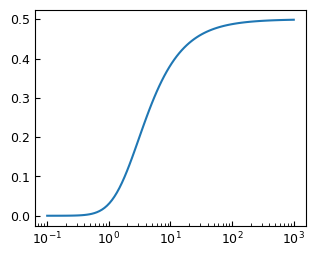

In [ ]:
c = np.logspace(-1,3,100)
y = Po_fit(c,10**0,10**0)
print(y)
plt.plot(c,y)
plt.xscale('log')

In [ ]:
import sys
sys.path.append('../src')
from src.bin_ligand_model import ec50_approx,ec50_hetero_from_homo

In [ ]:
Ko1,eps1 = .01,-15/5.
Ko2,eps2 = 0.0001,-15/5.

# The pool of available values
pool_Kos = [Ko1, Ko2]
pool_eps = [eps1,eps2]
# Generate all unique combinations of length 5
combos_Kos = list(combinations_with_replacement(pool_Kos, 5))
combos_eps = list(combinations_with_replacement(pool_eps, 5))

c12s = list()
for Kos,epss in zip(combos_Kos,combos_eps):
    c12s.append(c12(Kos,epss))
    display(Math(rf'C_{{1/2}} = {c12(Kos,epss):.2f}'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

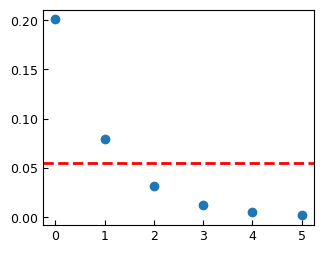

In [ ]:
plt.scatter(np.arange(0,c12s.__len__(),1),c12s)
plt.axhline(y=np.mean(c12s), color='r', linestyle='--', linewidth=2, label='Threshold')